# Stacked Bar Chart PDFs: Plotly, Matplotlib, and ReportLab
This notebook illustrates the differences in how plots are rendered and then saved to PDF files by 3 Python packages - Plotly, Matplotlib, and Reportlab. It serves as a companion to the blog post titled [Creating Data Visualisations with ReportLab](../content/posts/plotting_with_reportlab.md).

In [1]:
import io
import tempfile
import time
from pathlib import Path

import matplotlib.backends.backend_pdf as pdf_backend
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.utils import ImageReader
from reportlab.pdfgen import canvas as rl_canvas

## Generate Synthetic Data

In [2]:
NUM_PDFS = 5
PAGES_PER_PDF = 50
NUM_BARS = 28
SEGMENTS = ["Personnel", "Infrastructure", "Operations", "Marketing", "Other"]
rng = np.random.default_rng(42)

In [3]:
# Shape: (NUM_PDFS, PAGES_PER_PDF, NUM_BARS, len(SEGMENTS))
# Values 40–60 per segment → bar totals of ~200–300, varying ≤15% across charts
data = rng.integers(40, 61, size=(NUM_PDFS, PAGES_PER_PDF, NUM_BARS, len(SEGMENTS)))
Y_MAX = int(data.sum(axis=3).max() * 1.1)

In [ ]:
bar_labels = [f"Unit {i+1:02d}" for i in range(NUM_BARS)]
out_dir = Path(tempfile.mkdtemp())

## Approach 1: Plotly + Kaleido
Plotly generates interactive data visualisations that are primarily meant to be viewed in a browser. It uses Kaleido behind the scenes for rendering its plot. Kaleido's Chromium-based engine rasterises each `Figure` to a PNG, which is then pasted onto a PDF page via ReportLab. The per-page render cost is the bottleneck. This approach takes ~3 minutes to create a PDF file consisting of 50 plots.

In [5]:
def plotly_page(page_data: np.ndarray) -> go.Figure:
    fig = go.Figure([
        go.Bar(x=bar_labels, y=page_data[:, s], name=SEGMENTS[s])
        for s in range(len(SEGMENTS))
    ])
    fig.update_layout(barmode="stack", yaxis_range=[0, Y_MAX], showlegend=False)
    return fig

In [6]:
t0 = time.perf_counter()
for i in range(NUM_PDFS):
    c = rl_canvas.Canvas(str(out_dir / f"plotly_{i}.pdf"), pagesize=A4)
    for j in range(PAGES_PER_PDF):
        img_bytes = plotly_page(data[i, j]).to_image(format="png", width=840, height=595)
        c.drawImage(ImageReader(io.BytesIO(img_bytes)), 0, 0, width=A4[0], height=A4[1])
        c.showPage()
    c.save()
plotly_time = time.perf_counter() - t0
plotly_time

826.4650224579964

## Approach 2: Matplotlib
Matplotlib is the most well-known data visualisation package in the Python ecosystem. It creates static visualisations by default and is much faster than Plotly. The Matplotlib interface is granular enough so that if multiple visualisations share the same elements, they can be copied from one plot to the other without requring a re-render. But this trick only works when the plots are displayed on a screen using a backend like Tk or Qt. When saving a plot to a PDF file, Matplotlib converts the each plot to vector primitives so that it is rendered accurately in the file thereby eroding any time savings. 

As seen below, every PDF of 50 pages in this experiment in generated in 27 seconds which is a significant speed-up over Plotly.

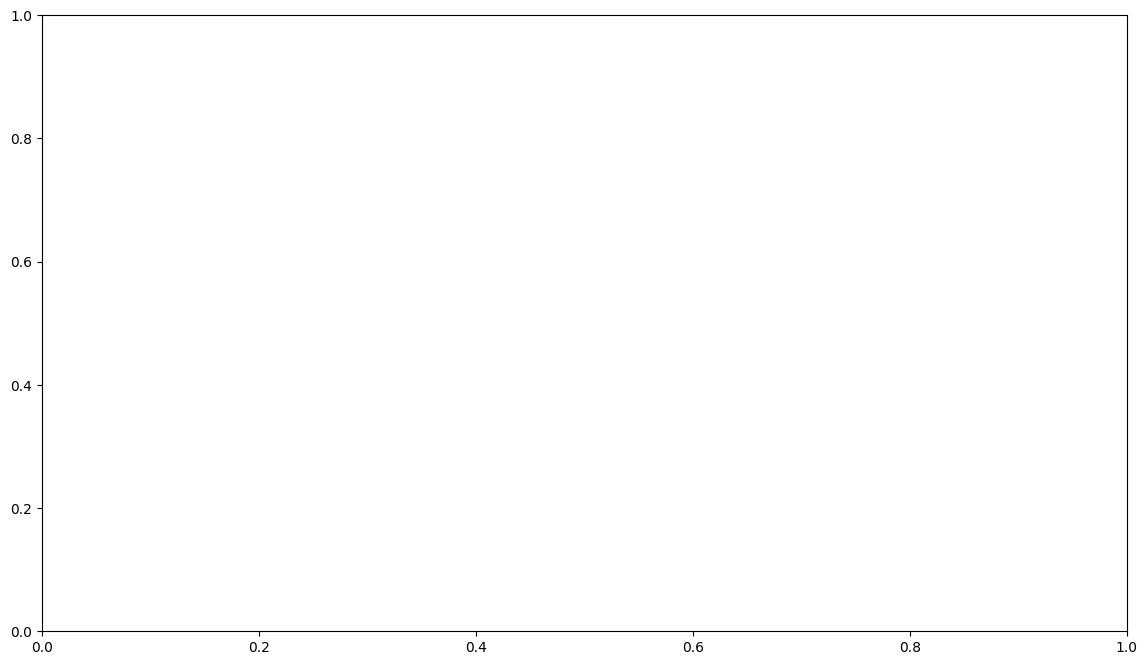

In [7]:
fig_mpl, ax_mpl = plt.subplots(figsize=(14, 8))
x_pos = np.arange(NUM_BARS)
MPL_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

In [8]:
t0 = time.perf_counter()
for i in range(NUM_PDFS):
    with pdf_backend.PdfPages(str(out_dir / f"mpl_{i}.pdf")) as pdf:
        for j in range(PAGES_PER_PDF):
            ax_mpl.cla()
            bottoms = np.zeros(NUM_BARS)
            for s, clr in zip(range(len(SEGMENTS)), MPL_COLORS):
                ax_mpl.bar(x_pos, data[i, j, :, s], bottom=bottoms, color=clr)
                bottoms += data[i, j, :, s]
            ax_mpl.set(xlim=(-0.5, NUM_BARS - 0.5), ylim=(0, Y_MAX), xticks=x_pos)
            pdf.savefig(fig_mpl)
plt.close(fig_mpl)
mpl_time = time.perf_counter() - t0
mpl_time

27.098178416956216

## Approach 3: ReportLab
ReportLab is a Python package that provides a granular API for rendering objects in a PDF precisely. It creates vector primitives that ensure that the visualisations scale according to changing screen resolutions. In some ways, it is reminiscent of the D3 API which allows developers to build a plot from scratch. Copilot and other AI-assistants know the ReportLab API quite well. The same PDF file is now generated in just ~2 seconds.

In [9]:
RL_COLORS = [
    colors.steelblue,
    colors.darkorange,
    colors.mediumseagreen,
    colors.indianred,
    colors.mediumpurple,
]
W, H = A4
CX, CY, CW, CH = 90.0, 75.0, W - 110, H - 115  # chart area in points

In [14]:
def rl_page(c: rl_canvas.Canvas, page_data: np.ndarray, title: str) -> None:
    slot = CW / NUM_BARS
    for bi in range(NUM_BARS):
        x, y = CX + bi * slot + slot * 0.1, CY
        for si, clr in enumerate(RL_COLORS):
            h = page_data[bi, si] / Y_MAX * CH
            c.setFillColor(clr)
            c.rect(x, y, slot * 0.8, h, fill=1, stroke=0)
            y += h
    c.setStrokeColor(colors.black)
    c.line(CX, CY, CX, CY + CH)
    c.line(CX, CY, CX + CW, CY)
    # Y-axis ticks and labels
    tick_step = 50
    c.setFont("Helvetica", 7)
    c.setFillColor(colors.black)
    v = 0
    while v <= Y_MAX:
        ty = CY + v / Y_MAX * CH
        c.line(CX - 4, ty, CX, ty)
        c.drawRightString(CX - 6, ty - 3, str(v))
        v += tick_step
    # X-axis ticks and labels (rotated 90°)
    c.setFont("Helvetica", 6)
    for bi, label in enumerate(bar_labels):
        tx = CX + bi * slot + slot * 0.5
        c.line(tx, CY, tx, CY - 4)
        c.saveState()
        c.translate(tx, CY - 6)
        c.rotate(90)
        c.drawRightString(0, 0, label)
        c.restoreState()
    c.setFillColor(colors.black)
    c.setFont("Helvetica-Bold", 11)
    c.drawCentredString(W / 2, H - 40, title)
    c.showPage()


In [15]:
t0 = time.perf_counter()
for i in range(NUM_PDFS):
    c = rl_canvas.Canvas(str(out_dir / f"rl_{i}.pdf"), pagesize=A4)
    for j in range(PAGES_PER_PDF):
        rl_page(c, data[i, j], f"Client {i + 1} \u2013 Period {j + 1}")
    c.save()
rl_time = time.perf_counter() - t0
rl_time

1.6732670420315117